# Synthetic Randomized-Treatment Smoke Test

## Causal Problem

The **unit of analysis** is one synthetic experimental unit, interpretable later as one customer. The **treatment** is a binary intervention $T_{i} \in \{0, 1\}$, defined as:

$$
T_i =
\begin{cases}
1 & \text{if unit } i \text{ received the treatment} \\
0 & \text{otherwise}
\end{cases}
$$

The **outcome** is a continuous post-treatment response measured over a single fixed horizon after treatment assignment.

In other words, each unit is a "synthetic customer", a single data point. Each one receives a binary treatment $T_{i}$ (0 or 1: whether it received the intervention or not), and produces a continuous **outcome** $Y_{i}$ (a number, like "response time" or "customer spending") **measured after the treatment**.

## The SCM (Structural Causal Model)

The SCM is literally a step-by-step "recipe" for how the data is created — it is the DGP (Data Generating Process) formalized in the following equations:

$$
SCM =
\begin{cases}
T_{i} \sim Bernoulli(p) & \text{each unit receives the treatment with probability p (a loaded coin)} \\
\epsilon_{i} \sim N(0, \sigma^{2}) & \text{an individual random noise, normally distributed} \\
Y_{i}(0) = \mu + \epsilon_{i} & \text{the potential outcome for unit i without the treatment} \\
Y_{i}(1) = Y_{i}(0) + \tau & \text{the potential outcome for \textbf{the same} unit i with the treatment} \\
Y_{i} = Y_{i}(0) + T_{i} \cdot \tau & \text{the outcome we actually observe}
\end{cases}
$$

### Translating the symbols

- $\mu$: the average outcome without the treatment
- $\epsilon_{i}$: an individual random noise, the "randomness" of each unit (why one person spends more than another, even without the treatment)
- $\tau$: the treatment's causal effect. It is the number that **we**, as the simulation's creators, know in advance and want to know whether the estimator can recover.
- $T_{i}$: 1 for the treated unit, 0 otherwise. It acts as a switch in the last equation: if $T_{i} = 1$ we add $\tau$; if $T_{i} = 0$ we add nothing.

## Potential Outcomes

$Y_{i}(0)$ and $Y_{i}(1)$ are the potential outcomes for the same unit: "what would happen to that person **without** the treatment" vs. "what would happen to that person **with** the treatment". **In real life, we can never observe the same unit both with and without treatment** — this is the **fundamental problem of causal inference**.

But in a simulation, we can do exactly that: we define both mathematically, so we can compare the estimator against the ground truth.

## ITE and ATE: the difference

- **ITE** (Individual Treatment Effect) = $Y_{i}(1) - Y_{i}(0)$ -> the causal effect for a specific unit.
- **ATE** (Average Treatment Effect) = $E[Y_{i}(1) - Y_{i}(0)]$ -> the average causal effect for the entire population.

Here, since $Y_{i}(1) = Y_{i}(0) + \tau$, the treatment always adds exactly $\tau$, with no variation between units, so we have

- $ITE = Y_{i}(1) - Y_{i}(0) = \tau$ for all units, always the same value.

This is a special, simplified case: the effect is **constant** (there is no effect heterogeneity), no single unit benefits more than another. That is why $ATE = \tau$: the average of many numbers that are all equal to $\tau$ is exactly $\tau$.

### "No confounders, mediators, colliders, or effect modifiers"

These are the classic causal-inference "villains" that this SCM deliberately **eliminates** to keep the test simple:

| Term | What it is | Why it doesn't exist here |
|---|---|---|
| **Confounder** | A variable that affects *both* the treatment *and* the outcome, creating a spurious correlation | $T_{i}$ comes from a pure, independent `Bernoulli` draw, independent of everything |
| **Mediator** | A variable on the "path" between treatment and outcome | There is no intermediate variable in the SCM |
| **Collider** | A variable affected by two other variables, which (if mistakenly controlled for) creates bias | This structure doesn't exist here |
| **Effect modifier** | Something that makes the treatment effect vary (e.g., the effect is larger for men than women) | The effect is always exactly $\tau$, constant |

### Why randomization "solves" everything: $T \bot (Y(0), Y(1))$

This symbol $\bot$ means **statistical independence**. The phrase says: *the treatment a unit receives has no relation to how it would respond in either hypothetical scenario.*

This is the foundation of why **RCTs (randomized controlled trials) work**: since who receives treatment is decided by a coin flip (not by the person's characteristics), the treated group and the control group are, in expectation, **statistically equivalent in every way** — the only systematic difference between them is the treatment itself. That's why you can compare the two groups' averages and attribute the difference to $\tau$, without worrying about confounding.

### Consistency: $Y = Y(T)$

It seems obvious, but it's an important formal assumption: **the observed outcome is exactly the potential outcome corresponding to the treatment that actually happened**, no "different versions" of the treatment (it doesn't matter *how* the person was treated, only *whether* they were), and no unit affecting another unit's response (**no interference**, also called SUTVA in the literature).

### Positivity: $0 < p < 1$

This guarantees that, in the population, **there's a real chance of ending up in either of the two groups** — neither 0% nor 100% probability of treatment. If $p = 1$, for example, no one would ever be in the control group, and you'd have nothing to compare against.

In [1]:
"""Simple randomized-treatment simulation with known causal ground truth."""

import numpy as np
from numpy.typing import NDArray

from causallift.simulations.randomness import create_rng

IntArray = NDArray[np.int64]
FloatArray = NDArray[np.float64]


def simulate_randomized_trial(
    *,
    n: int,
    treatment_probability: float,
    baseline_mean: float,
    treatment_effect: float,
    outcome_noise_sd: float,
    seed: int,
) -> tuple[IntArray, FloatArray, FloatArray, FloatArray]:
    """Simulate a randomized trial with a constant additive treatment effect.

    Structural equations:

        T ~ Bernoulli(treatment_probability)
        Y(0) = baseline_mean + epsilon
        Y(1) = Y(0) + treatment_effect
        Y = Y(0) + T * treatment_effect

    where epsilon ~ Normal(0, outcome_noise_sd**2) independently of treatment.

    Returns:
        treatment, observed_outcome, potential_outcome_0, potential_outcome_1
    """
    if n <= 0:
        raise ValueError("n must be positive")

    if not 0.0 < treatment_probability < 1.0:
        raise ValueError("treatment_probability must be strictly between 0 and 1")

    if outcome_noise_sd < 0.0:
        raise ValueError("outcome_noise_sd must be non-negative")

    rng = create_rng(seed)

    treatment = rng.binomial(
        n=1,
        p=treatment_probability,
        size=n,
    ).astype(np.int64)

    noise = rng.normal(
        loc=0.0,
        scale=outcome_noise_sd,
        size=n,
    )

    potential_outcome_0 = baseline_mean + noise
    potential_outcome_1 = potential_outcome_0 + treatment_effect
    observed_outcome = potential_outcome_0 + treatment * treatment_effect

    return (
        treatment,
        observed_outcome,
        potential_outcome_0,
        potential_outcome_1,
    )


def difference_in_means(
    treatment: IntArray,
    outcome: FloatArray,
) -> float:
    """Estimate the ATE as treated mean outcome minus control mean outcome."""
    if treatment.ndim != 1 or outcome.ndim != 1:
        raise ValueError("treatment and outcome must be one-dimensional")

    if treatment.shape != outcome.shape:
        raise ValueError("treatment and outcome must have the same shape")

    if not np.all((treatment == 0) | (treatment == 1)):
        raise ValueError("treatment must contain only 0 and 1")

    treated = outcome[treatment == 1]
    control = outcome[treatment == 0]

    if treated.size == 0 or control.size == 0:
        raise ValueError("both treatment arms must be present")

    return float(np.mean(treated) - np.mean(control))

In [2]:
N = 20_000
TREATMENT_PROBABILITY = 0.5
BASELINE_MEAN = 10.0
NOISE_SD = 1.0
TREATMENT_EFFECT = 2.0
SEED = 42

In [3]:
treatment, outcome, potential_outcome_0, potential_outcome_1 = (
    simulate_randomized_trial(
        n=N,
        treatment_probability=TREATMENT_PROBABILITY,
        baseline_mean=BASELINE_MEAN,
        treatment_effect=TREATMENT_EFFECT,
        outcome_noise_sd=NOISE_SD,
        seed=SEED,
    )
)

## Analyzing the Simulation Results

Now that `simulate_randomized_trial` has generated the synthetic data, let's check  with numbers and plots  whether the simulation behaves as the SCM predicts:

1. **Balance**: did randomization split the units into treated/control in the expected proportion?
2. **Outcome distribution**: are the two arms' distributions shifted by roughly $\tau$?
3. **ATE recovery**: does the *difference-in-means* estimator recover the true $\tau$ (which we only know because this is a simulation)?
4. **Constant effect**: does $Y_i(1) = Y_i(0) + \tau$ hold exactly for every unit, confirming the absence of effect heterogeneity described above?

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Consistent style for every plot in this notebook
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#52514e",
        "axes.labelcolor": "#0b0b0b",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e5e4df",
        "grid.linewidth": 0.6,
        "text.color": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "legend.frameon": False,
    }
)

# Categorical palette: control = blue, treated = orange (used across all plots)
COLOR_CONTROL = "#2a78d6"
COLOR_TREATED = "#eb6834"

df = pd.DataFrame(
    {
        "treatment": treatment,
        "outcome": outcome,
        "potential_outcome_0": potential_outcome_0,
        "potential_outcome_1": potential_outcome_1,
    }
)
df["ite"] = df["potential_outcome_1"] - df["potential_outcome_0"]
df["arm"] = df["treatment"].map({0: "Control (T=0)", 1: "Treated (T=1)"})

df.head()

,treatment,outcome,potential_outcome_0,potential_outcome_1,ite,arm
0,1,10.174228,8.174228,10.174228,2.0,Treated (T=1)
1,0,9.605312,9.605312,11.605312,2.0,Control (T=0)
2,1,10.251599,8.251599,10.251599,2.0,Treated (T=1)
3,1,14.041539,12.041539,14.041539,2.0,Treated (T=1)
4,0,10.212491,10.212491,12.212491,2.0,Control (T=0)


### 1. Randomization balance

With `N = 20,000` and `treatment_probability = 0.5`, we expect ~10,000 units in each arm. This illustrates **positivity** ($0 < p < 1$): both groups exist in sufficient size for comparison.

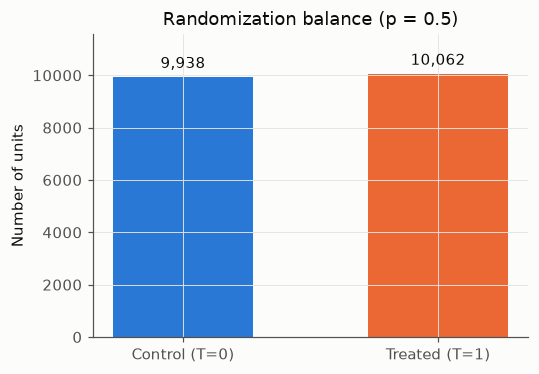

Observed treated proportion: 0.5031  (target: 0.5)


In [5]:
counts = df["arm"].value_counts().reindex(["Control (T=0)", "Treated (T=1)"])
proportion_treated = df["treatment"].mean()

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(
    counts.index, counts.values, color=[COLOR_CONTROL, COLOR_TREATED], width=0.55
)
for bar, value in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + counts.max() * 0.02,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylabel("Number of units")
ax.set_title(f"Randomization balance (p = {TREATMENT_PROBABILITY})")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

print(
    f"Observed treated proportion: {proportion_treated:.4f}  (target: {TREATMENT_PROBABILITY})"
)

### 2. Distribution of the observed outcome by arm

Each treated unit receives a "push" of exactly $\tau = 2.0$ on top of its $Y(0)$. Since the noise $\epsilon_i \sim N(0, 1)$ is the same in both groups (randomization doesn't affect the noise), we expect:

- Two distributions with **the same shape and spread** (same $\sigma$), just **shifted** relative to each other.
- The gap between the means should be close to $\tau$.
- Considerable overlap between the curves: the individual noise ($\sigma=1$) is of the same order of magnitude as the effect ($\tau=2$), so you can't tell whether a given individual was treated just by looking at their outcome  only the group mean reveals the effect.

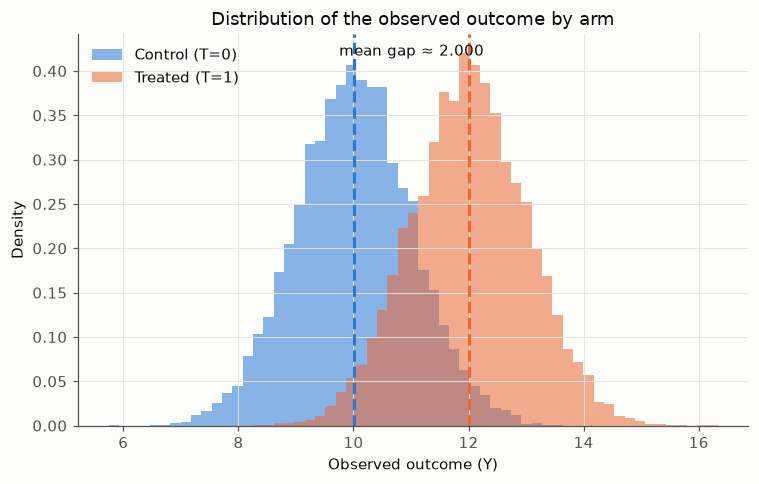

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(df["outcome"].min(), df["outcome"].max(), 60)

ax.hist(
    df.loc[df["treatment"] == 0, "outcome"],
    bins=bins,
    color=COLOR_CONTROL,
    alpha=0.55,
    density=True,
    label="Control (T=0)",
)
ax.hist(
    df.loc[df["treatment"] == 1, "outcome"],
    bins=bins,
    color=COLOR_TREATED,
    alpha=0.55,
    density=True,
    label="Treated (T=1)",
)

mean_control = df.loc[df["treatment"] == 0, "outcome"].mean()
mean_treated = df.loc[df["treatment"] == 1, "outcome"].mean()
ax.axvline(mean_control, color=COLOR_CONTROL, linestyle="--", linewidth=2)
ax.axvline(mean_treated, color=COLOR_TREATED, linestyle="--", linewidth=2)
ax.annotate(
    f"mean gap ≈ {mean_treated - mean_control:.3f}",
    xy=((mean_control + mean_treated) / 2, ax.get_ylim()[1]),
    xytext=(0, -14),
    textcoords="offset points",
    ha="center",
    fontsize=10,
)

ax.set_xlabel("Observed outcome (Y)")
ax.set_ylabel("Density")
ax.set_title("Distribution of the observed outcome by arm")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 3. Does the estimator recover the true $\tau$?

`difference_in_means` computes $\hat{ATE} = \bar{Y}_{treated} - \bar{Y}_{control}$. Since randomization guarantees $T \bot (Y(0), Y(1))$, this simple estimator is **unbiased** for the ATE  we don't need any adjustment for confounders (there are none).

To visualize the sampling uncertainty, we build a 95% confidence interval via *bootstrap* (resampling the 20,000 units with replacement) and compare it against the $\tau=2.0$ we used to generate the data.

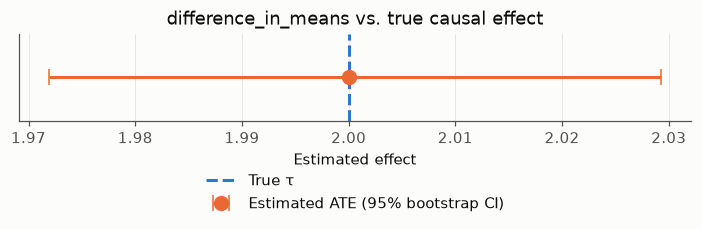

Estimated ATE (difference in means): 2.0000
95% bootstrap CI:                    [1.9719, 2.0292]
True τ (ground truth):               2.0
Absolute error:                      0.0000


In [7]:
ate_hat = difference_in_means(treatment, outcome)

boot_rng = np.random.default_rng(SEED)
n_boot = 2_000
boot_estimates = np.empty(n_boot)
row_idx = np.arange(N)
for b in range(n_boot):
    sample = boot_rng.choice(row_idx, size=N, replace=True)
    boot_estimates[b] = difference_in_means(treatment[sample], outcome[sample])

ci_low, ci_high = np.percentile(boot_estimates, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.errorbar(
    [ate_hat],
    [0],
    xerr=[[ate_hat - ci_low], [ci_high - ate_hat]],
    fmt="o",
    color=COLOR_TREATED,
    ecolor=COLOR_TREATED,
    elinewidth=2,
    capsize=5,
    markersize=9,
    label="Estimated ATE (95% bootstrap CI)",
)
ax.axvline(
    TREATMENT_EFFECT, color=COLOR_CONTROL, linestyle="--", linewidth=2, label="True τ"
)
ax.set_yticks([])
ax.set_xlabel("Estimated effect")
ax.set_title("difference_in_means vs. true causal effect")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=1)
plt.tight_layout()
plt.show()

print(f"Estimated ATE (difference in means): {ate_hat:.4f}")
print(f"95% bootstrap CI:                    [{ci_low:.4f}, {ci_high:.4f}]")
print(f"True τ (ground truth):               {TREATMENT_EFFECT}")
print(f"Absolute error:                      {abs(ate_hat - TREATMENT_EFFECT):.4f}")

### 4. Constant effect: $Y_i(1) = Y_i(0) + \tau$ for every unit

Unlike observational data, here we have access to **both** potential outcomes for each unit (only because this is a simulation). This lets us directly verify the SCM's homogeneous-effect assumption: plotting $Y(1)$ against $Y(0)$, every point should fall **exactly** on the line $y = x + \tau$, with no deviation, that is the definition of $ITE_i = \tau$ for every $i$, and that's why $ATE = E[ITE_i] = \tau$ as well.

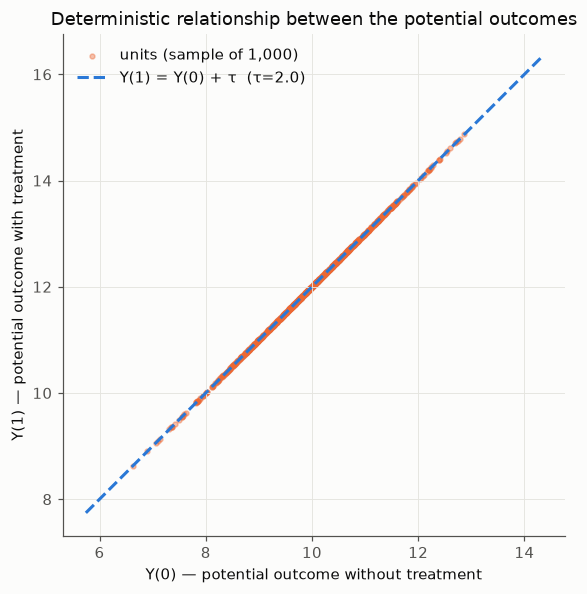

Unique ITE value observed in the simulation: [2. 2. 2. 2.]
ITE standard deviation: 7.40e-17  (should be ~0, up to floating-point error)


In [8]:
plot_rng = np.random.default_rng(SEED)
sample_idx = plot_rng.choice(N, size=1_000, replace=False)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(
    df["potential_outcome_0"].to_numpy()[sample_idx],
    df["potential_outcome_1"].to_numpy()[sample_idx],
    s=10,
    alpha=0.4,
    color=COLOR_TREATED,
    label="units (sample of 1,000)",
)
lims = np.array([df["potential_outcome_0"].min(), df["potential_outcome_0"].max()])
ax.plot(
    lims,
    lims + TREATMENT_EFFECT,
    color=COLOR_CONTROL,
    linestyle="--",
    linewidth=2,
    label=f"Y(1) = Y(0) + τ  (τ={TREATMENT_EFFECT})",
)

ax.set_xlabel("Y(0) — potential outcome without treatment")
ax.set_ylabel("Y(1) — potential outcome with treatment")
ax.set_title("Deterministic relationship between the potential outcomes")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Unique ITE value observed in the simulation: {df['ite'].unique()}")
print(
    f"ITE standard deviation: {df['ite'].std():.2e}  (should be ~0, up to floating-point error)"
)

## Summary

The four checks confirm, in practice, what the SCM promised in theory:

- **Balance**: ~50/50 split between arms, as expected from `Bernoulli(0.5)` positivity satisfied.
- **Outcome distribution**: the two distributions have the same shape (same $\sigma=1$), just shifted by the gap between means, which comes out very close to $\tau=2.0$  visual evidence that $T \bot (Y(0), Y(1))$ holds (no confounder distorting the groups).
- **ATE recovery**: `difference_in_means` estimates something very close to $\tau$, with the 95% CI covering the true value  the simple estimator works because randomization removes the need for any confounder adjustment.
- **Constant effect**: every point in the $Y(1)$ vs. $Y(0)$ plot falls exactly on the line $y=x+\tau$, confirming that $ITE_i = \tau$ for every unit and, therefore, $ATE = \tau$ exactly (not just in expectation).

This is the expected behavior of a **smoke test**: if any of these checks failed (unbalanced groups, a gap far from $\tau$, a CI that doesn't cover $\tau$, ITE varying across units), it would signal a bug in the `simulate_randomized_trial` function or in the random number generator (`create_rng`), not a causal-inference issue per se.